<a href="https://colab.research.google.com/github/Ayesha-coder317/Portfolio/blob/Machine-Learning/MachineLearning_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA


In [ ]:
# Setting up Libararies

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [ ]:
path = "/content/drive/MyDrive/DS and AI/EDA/cars_price (1) - cars_price (1).csv"
df = pd.read_csv(path)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3.0,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,NaN,2548.0,dohc,NaN,NaN,mpfi,3.47,2.68,9.0,111,NaN,21.0,27.0,13495
1,3.0,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548.0,NaN,four,130.0,mpfi,3.47,2.68,9.0,111,NaN,21.0,27.0,16500
2,1.0,?,alfa-romero,gas,std,two,hatchback,rwd,NaN,94.5,171.2,65.5,52.4,2823.0,ohcv,six,152.0,mpfi,NaN,3.47,9.0,154,NaN,19.0,26.0,16500
3,2.0,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337.0,ohc,four,109.0,mpfi,3.19,NaN,10.0,102,5500,24.0,30.0,13950
4,2.0,164,audi,gas,std,NaN,sedan,4wd,front,99.4,NaN,NaN,54.3,2824.0,NaN,five,136.0,mpfi,NaN,3.4,8.0,115,5500,18.0,22.0,17450


In [ ]:
print("Shape:", df.shape)

missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values per column:\n", missing[missing > 0])

print("\nDtypes:\n", df.dtypes)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)


Shape: (30330, 26)

Missing values per column:
 horsepower           3148
drive-wheels         3115
make                 3102
city-mpg             3101
fuel-system          3081
length               3072
wheel-base           3066
engine-size          3059
height               3049
engine-type          3045
symboling            3044
price                3043
normalized-losses    3036
num-of-cylinders     3032
curb-weight          3028
highway-mpg          3027
fuel-type            3021
num-of-doors         3009
body-style           3004
compression-ratio    3003
peak-rpm             2999
engine-location      2978
aspiration           2975
bore                 2957
width                2943
stroke               2921
dtype: int64

Dtypes:
 symboling            float64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location      

In [ ]:
df.dtypes


,0
symboling,float64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


In [ ]:
# Object to numeric data type

object_cols = df.select_dtypes(include="object").columns

potential_numeric = []
for col in object_cols:
    sample = df[col].dropna().astype(str).head(10)
    if sample.str.contains(r"\d").any():
        potential_numeric.append(col)

potential_numeric

['normalized-losses',
 'drive-wheels',
 'bore',
 'stroke',
 'horsepower',
 'peak-rpm',
 'price']

In [ ]:
# Cleaning and converting numeric columns

for col in potential_numeric:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=True)
        .str.replace(r"[^\d\.]", "", regex=True)  # remove currency symbols & text
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [ ]:
# Updating date columns to datetime

for col in df.select_dtypes(include="object").columns:
    try:
        converted = pd.to_datetime(df[col], errors="coerce")
        if converted.notna().sum() > 0.7 * len(df):
            df[col] = converted
            print(f"Converted {col} to datetime")
    except:
        pass



/tmp/ipython-input-179386008.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(df[col], errors="coerce")
/tmp/ipython-input-179386008.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(df[col], errors="coerce")
/tmp/ipython-input-179386008.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(df[col], errors="coerce")
/tmp/ipython-input-179386008.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent a

In [ ]:
# Normalise binary columns

binary_mappings = {
    "yes": 1, "no": 0,
    "true": 1, "false": 0
}

for col in df.select_dtypes(include="object").columns:
    unique_vals = df[col].dropna().str.lower().unique()
    if set(unique_vals).issubset(binary_mappings.keys()):
        df[col] = df[col].str.lower().map(binary_mappings)
        print(f"Converted {col} to binary (0/1)")

In [ ]:
# Converting obj to categorical to improve memory usage and provide clarity

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")

In [ ]:
df.dtypes


,0
symboling,float64
normalized-losses,float64
make,category
fuel-type,category
aspiration,category
num-of-doors,category
body-style,category
drive-wheels,float64
engine-location,category
wheel-base,float64


During exploratory data analysis, all columns were validated for correct data types. Numeric variables stored as text due to formatting issues (such as currency symbols and commas) were cleaned and converted to numeric format. Date-related columns were converted to datetime objects where applicable. Binary categorical variables were standardized into 0/1 format, and remaining text columns were explicitly cast as categorical variables. This ensured data consistency and correctness before preprocessing and model training.

In [ ]:
# Descriptive Statistics

df.describe()

,symboling,normalized-losses,drive-wheels,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,27286.000000,21768.000000,1264.0,27264.000000,27258.000000,27387.000000,27281.000000,27302.000000,27271.000000,26842.000000,26877.000000,27327.000000,26922.000000,27081.000000,27229.000000,27303.000000,26724.000000
mean,0.839075,122.348447,4.0,98.807875,174.158302,65.918114,53.732059,2560.265988,127.322834,3.330761,3.256885,10.128243,104.631342,5121.598168,25.158507,30.709885,13235.159145
std,1.239600,35.466905,0.0,6.037800,12.366150,2.143679,2.438541,522.483478,41.863332,0.271512,0.316256,3.943566,39.771595,478.959908,6.517298,6.862626,7954.952152
min,-2.000000,65.000000,4.0,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,4.0,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.500000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,4.0,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,4.0,102.400000,183.500000,66.900000,55.500000,2954.000000,146.000000,3.590000,3.410000,9.400000,120.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,4.0,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['symboling', 'normalized-losses', 'drive-wheels', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm',
       'city-mpg', 'highway-mpg', 'price'],
      dtype='object')

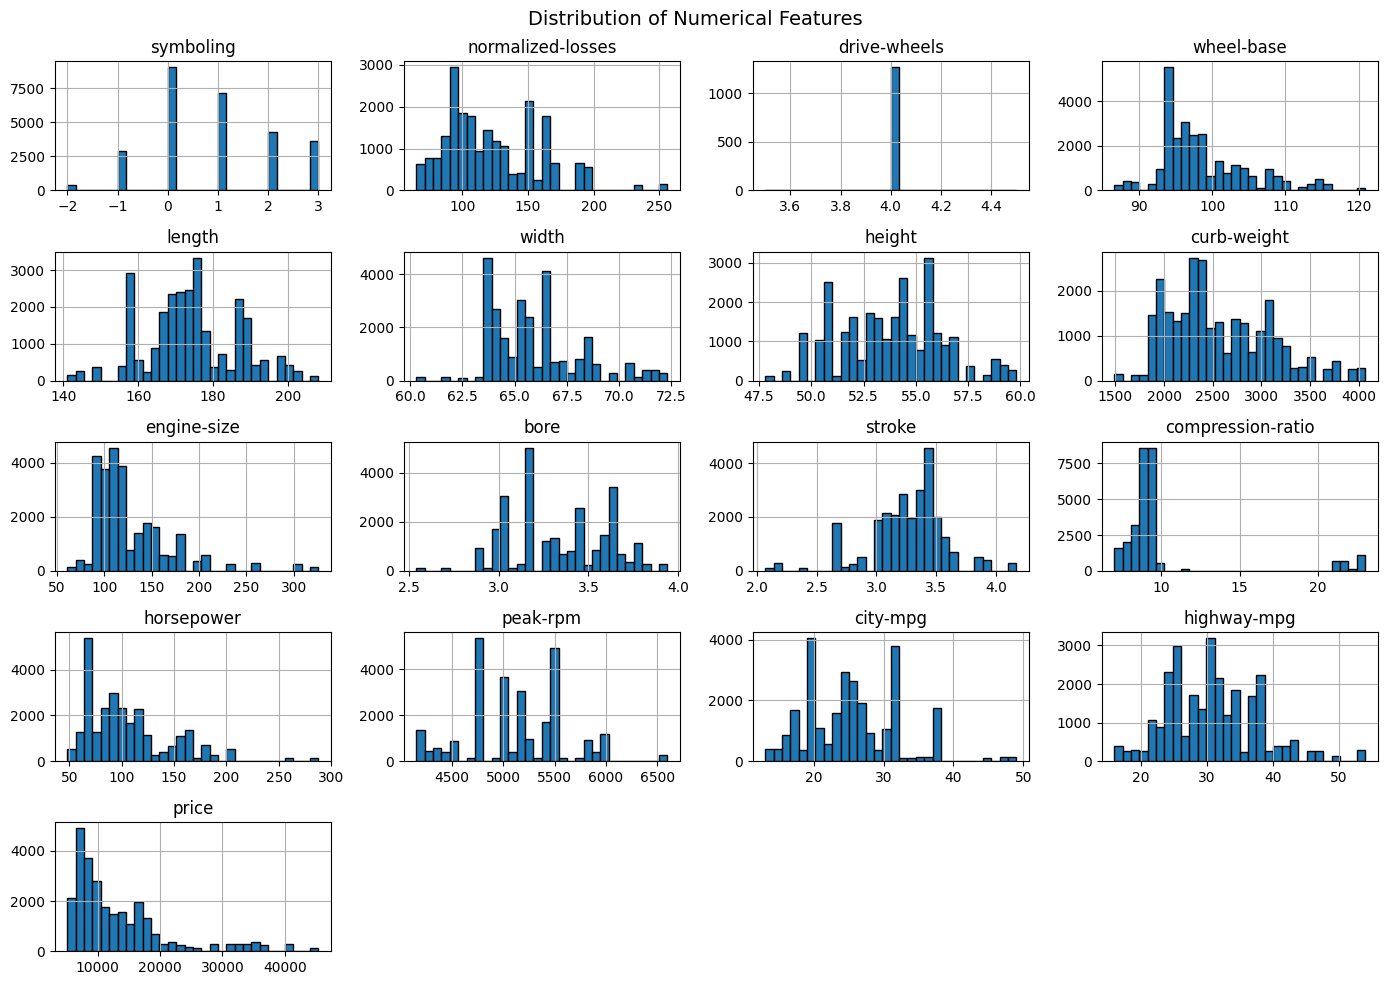

In [ ]:
# Plot histograms

df[numeric_cols].hist(
    bins=30,
    figsize=(14, 10),
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

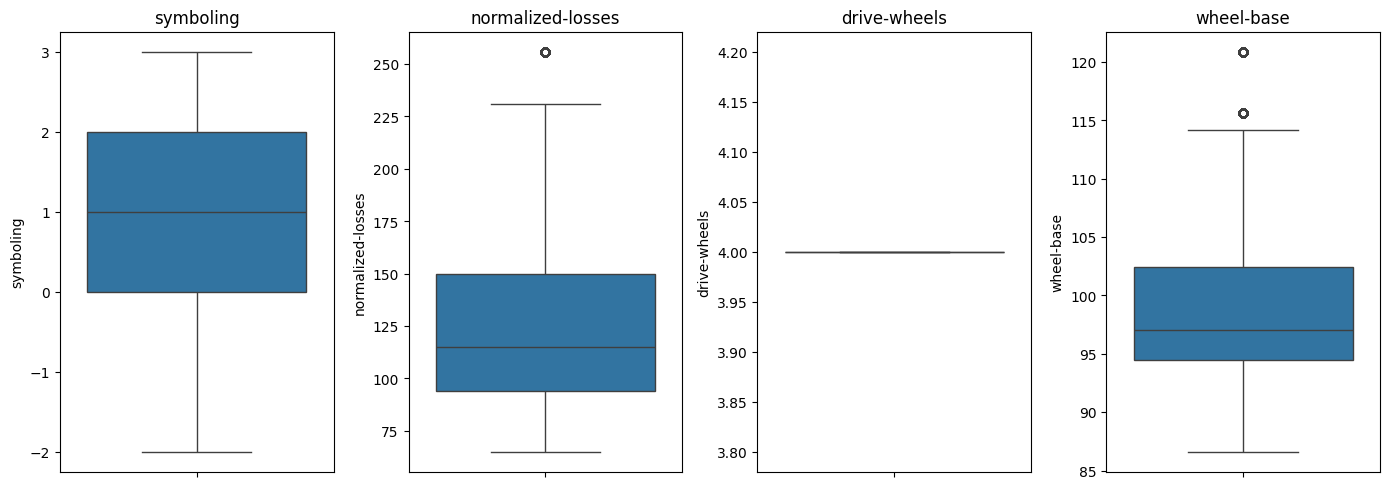

In [ ]:
# outlier detection

boxplot_cols = numeric_cols[:4]

plt.figure(figsize=(14, 5))
for i, col in enumerate(boxplot_cols, 1):
    plt.subplot(1, len(boxplot_cols), i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


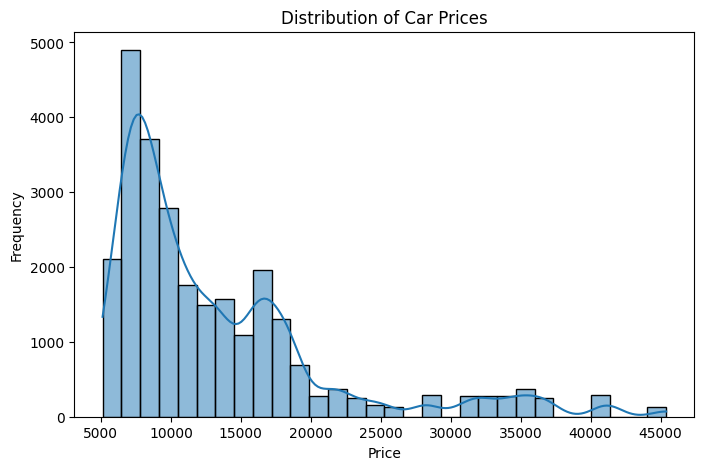

In [ ]:
# focused distribution for price

target = "price"

plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=30, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# Correlation Matrix

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

corr_matrix = df[numeric_cols].corr()
corr_matrix

,symboling,normalized-losses,drive-wheels,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
symboling,1.000000,0.523621,NaN,-0.529495,-0.356977,-0.236249,-0.535374,-0.232535,-0.114209,-0.134653,-0.002948,-0.180388,0.065870,0.276940,-0.034452,0.038424,-0.096681
normalized-losses,0.523621,1.000000,NaN,-0.063380,0.030514,0.106879,-0.430806,0.123893,0.175768,-0.033138,0.073164,-0.129297,0.304372,0.255267,-0.265807,-0.218382,0.202391
drive-wheels,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheel-base,-0.529495,-0.063380,NaN,1.000000,0.876636,0.799274,0.585778,0.781349,0.579872,0.499127,0.173786,0.269613,0.360241,-0.369098,-0.473409,-0.549366,0.600242
length,-0.356977,0.030514,NaN,0.876636,1.000000,0.845232,0.489149,0.880236,0.691772,0.615879,0.144178,0.165914,0.562258,-0.291603,-0.678502,-0.710426,0.698604
width,-0.236249,0.106879,NaN,0.799274,0.845232,1.000000,0.281566,0.867494,0.738486,0.567084,0.192517,0.195014,0.644749,-0.221912,-0.646016,-0.678215,0.753180
height,-0.535374,-0.430806,NaN,0.585778,0.489149,0.281566,1.000000,0.300742,0.073045,0.178919,-0.059233,0.270311,-0.109973,-0.330689,-0.046585,-0.108288,0.147524
curb-weight,-0.232535,0.123893,NaN,0.781349,0.880236,0.867494,0.300742,1.000000,0.852962,0.650561,0.184605,0.167659,0.750683,-0.274719,-0.758752,-0.797958,0.834655
engine-size,-0.114209,0.175768,NaN,0.579872,0.691772,0.738486,0.073045,0.852962,1.000000,0.594639,0.224036,0.041595,0.811478,-0.251772,-0.658087,-0.679744,0.873152
bore,-0.134653,-0.033138,NaN,0.499127,0.615879,0.567084,0.178919,0.650561,0.594639,1.000000,-0.051514,0.023861,0.576029,-0.278632,-0.597915,-0.596227,0.544550


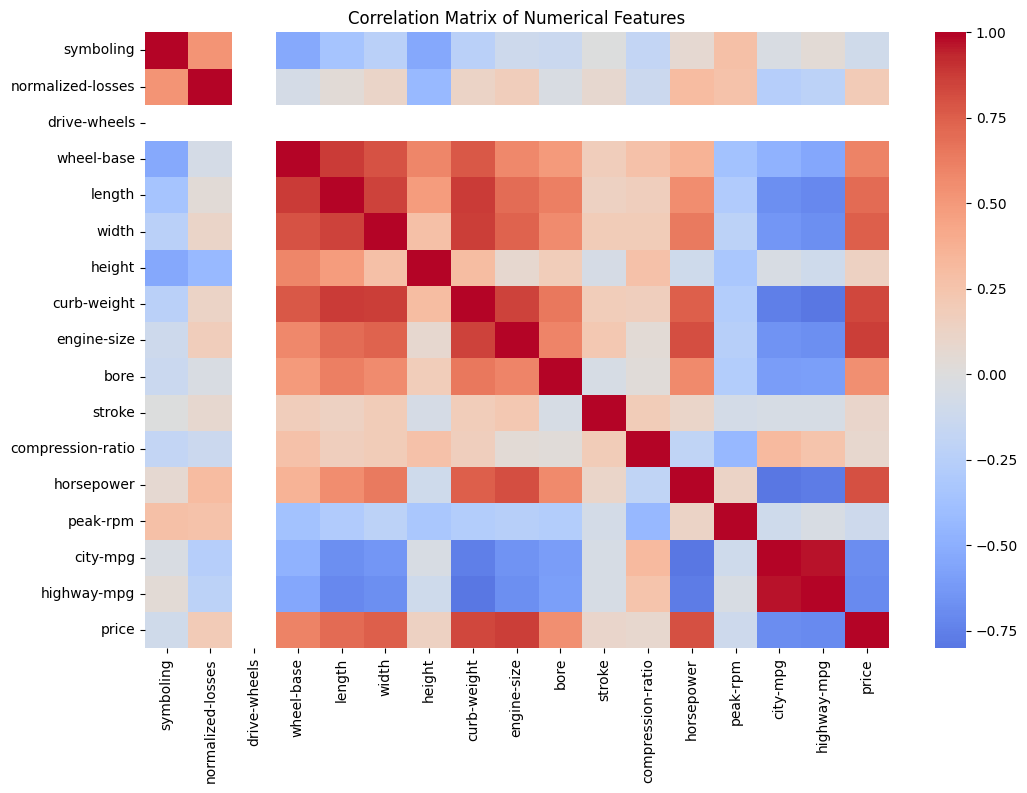

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [ ]:
# Correlation with target

price_corr = corr_matrix[target].sort_values(ascending=False)
price_corr

,price
price,1.000000
engine-size,0.873152
curb-weight,0.834655
horsepower,0.808240
width,0.753180
length,0.698604
wheel-base,0.600242
bore,0.544550
normalized-losses,0.202391
height,0.147524


In [ ]:
# Identifying categorical feature i.e fuel type

fuel_cols = [c for c in df.columns if "fuel" in c.lower()]
fuel_col = fuel_cols[0] if fuel_cols else None

fuel_col

'fuel-type'

We search for a column related to fuel type, which is commonly categorical and influential in car pricing.

In [ ]:
# Pivot Table
fuel_price_pivot = pd.pivot_table(
    df,
    values=target,
    index=fuel_col,
    aggfunc="mean",
    observed=False   # explicitly specify behavior
)

fuel_price_pivot.sort_values(by=target, ascending=False)



,price
fuel-type,
diesel,16106.236786
gas,12923.557840


In [ ]:
# GroupBy Analysis: brand vs Price

brand_cols = [
    c for c in df.columns
    if "brand" in c.lower() or "make" in c.lower() or "company" in c.lower()
]
brand_col = brand_cols[0] if brand_cols else None

brand_col

'make'

Car brand/manufacturer is a key categorical variable affecting price.
We detect it programmatically to avoid hard-coding.

In [ ]:
# Avg price by brand
brand_price = (
    df
    .groupby(brand_col, observed=False)[target]
    .mean()
    .sort_values(ascending=False)
)

brand_price.head(10)

,price
make,
jaguar,34389.893617
mercedes-benz,33518.010406
porsche,31299.036036
bmw,26720.230461
volvo,18120.512924
audi,17844.668142
mercury,16503.000000
alfa-romero,15492.829670
peugot,15450.178704


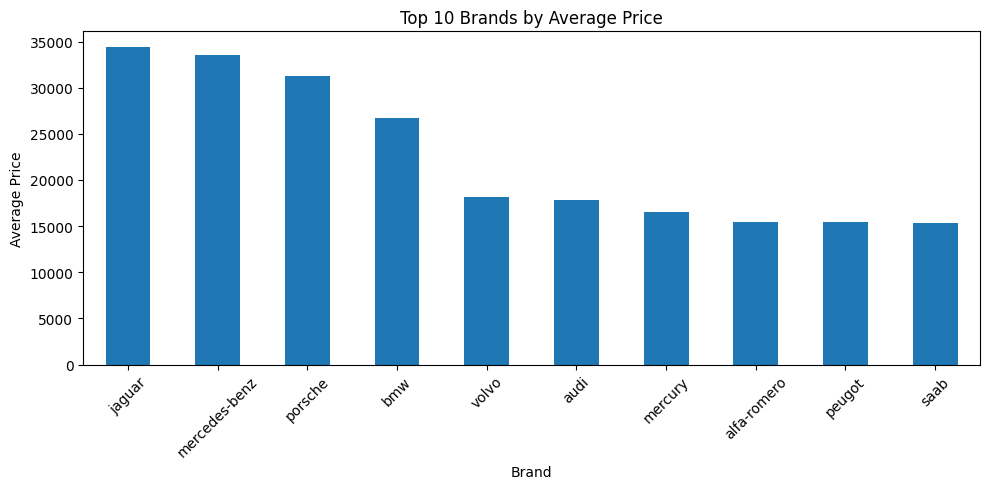

In [ ]:
# brand impact on price

plt.figure(figsize=(10, 5))
brand_price.head(10).plot(kind="bar")
plt.title("Top 10 Brands by Average Price")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


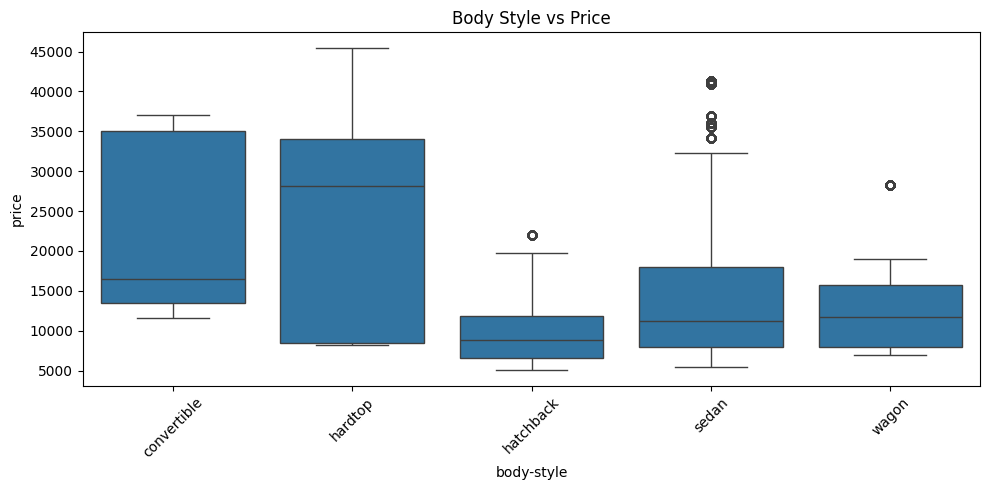

In [ ]:
# body price vs price


body_cols = [
    c for c in df.columns
    if "body" in c.lower() and "style" in c.lower()
]

if len(body_cols) == 0:
    raise ValueError("No body style column found. Check column names.")

body_col = body_cols[0]
body_col

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x=body_col, y=target)
plt.title("Body Style vs Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Data Preprocessing

In [ ]:
# define x and y

y = df[target]

X = df.drop(columns=[target])

X.shape, y.shape


((30330, 25), (30330,))

In [ ]:
# Remove rows where target is missing
mask = y.notna()
X = X[mask]
y = y[mask]

X.shape, y.shape


((26724, 25), (26724,))

In [ ]:
# Train and Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train.shape, X_test.shape


((21379, 25), (5345, 25))

In [ ]:
# verifying column types

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["category"]).columns
datetime_features = X_train.select_dtypes(include=["datetime64"]).columns

numeric_features, categorical_features, datetime_features


(Index(['symboling', 'normalized-losses', 'drive-wheels', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm',
        'city-mpg', 'highway-mpg'],
       dtype='object'),
 Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system'], dtype='object'),
 Index([], dtype='object'))

In [ ]:
# Year and month extraction

for col in datetime_features:
    X_train[col + "_year"] = X_train[col].dt.year
    X_test[col + "_year"] = X_test[col].dt.year

    X_train[col + "_month"] = X_train[col].dt.month
    X_test[col + "_month"] = X_test[col].dt.month

# Drop original datetime columns
X_train = X_train.drop(columns=datetime_features)
X_test = X_test.drop(columns=datetime_features)

X_train.shape

(21379, 25)

In [ ]:
#   imputation

from sklearn.impute import SimpleImputer

# Median for numeric (robust to outliers)
num_imputer = SimpleImputer(strategy="median")

# Most frequent for categorical
cat_imputer = SimpleImputer(strategy="most_frequent")

# Numeric imputation
X_train[numeric_features] = num_imputer.fit_transform(X_train[numeric_features])
X_test[numeric_features] = num_imputer.transform(X_test[numeric_features])

# Categorical imputation
X_train[categorical_features] = cat_imputer.fit_transform(X_train[categorical_features])
X_test[categorical_features] = cat_imputer.transform(X_test[categorical_features])



In [ ]:
# one hot encoding

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])


In [ ]:
# Rebuild dataframes

encoded_cols = encoder.get_feature_names_out(categorical_features)

X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=encoded_cols,
    index=X_train.index
)

X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=encoded_cols,
    index=X_test.index
)

# Combine numeric + encoded categorical features
X_train_final = pd.concat([X_train[numeric_features], X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test[numeric_features], X_test_cat_df], axis=1)

X_train_final.shape, X_test_final.shape


((21379, 73), (5345, 73))

In [ ]:
# Standardization for KNN

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)



In this step, the dataset was prepared for modeling by separating features and target variables, handling missing values through appropriate imputation strategies, encoding categorical variables using one-hot encoding, and scaling numerical features where required. The data was split into training and testing sets prior to preprocessing to prevent data leakage. This ensured that the final datasets were clean, numeric, and suitable for machine learning models.

# Model Building

In [ ]:

print("X_train exists:", "X_train" in globals())
print("numeric_features exists:", "numeric_features" in globals())
print("categorical_features exists:", "categorical_features" in globals())


X_train exists: True
numeric_features exists: True
categorical_features exists: True


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Encode categorical features
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

# Convert to DataFrame
encoded_cols = encoder.get_feature_names_out(categorical_features)

X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=encoded_cols,
    index=X_train.index
)

X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=encoded_cols,
    index=X_test.index
)

# Combine numeric + categorical
X_train_final = pd.concat([X_train[numeric_features], X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test[numeric_features], X_test_cat_df], axis=1)

X_train_final.shape, X_test_final.shape


((21379, 73), (5345, 73))

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)


In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train_final, y_train)


LinearRegression()

In [ ]:
# Make predictions on test data
y_pred_lr = linear_model.predict(X_test_final)

# Evaluate performance
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mse_lr, r2_lr


(4588455.9730513785, 0.926164837042678)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the model
tree_model = DecisionTreeRegressor(random_state=42)

# Train the model
tree_model.fit(X_train_final, y_train)


DecisionTreeRegressor(random_state=42)

In [ ]:
# Predictions on test data
y_pred_tree = tree_model.predict(X_test_final)

# Evaluation
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

mse_tree, r2_tree


(432500.5463346941, 0.9930404152278448)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize KNN with k=5
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train model using scaled data
knn_model.fit(X_train_scaled, y_train)


KNeighborsRegressor()

In [ ]:
# Predictions on test data
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluation
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

mse_knn, r2_knn


(715502.7380430308, 0.9884864840002627)

In [ ]:
k_values = range(3, 16, 2)
knn_results = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)

    knn_results.append({
        "k": k,
        "MSE": mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    })

knn_results_df = pd.DataFrame(knn_results)
knn_results_df


,k,MSE,R2
0,3,662760.826047,0.989335
1,5,715502.738043,0.988486
2,7,786551.219068,0.987343
3,9,860384.919796,0.986155
4,11,908731.800881,0.985377
5,13,954374.789827,0.984643
6,15,998295.787430,0.983936


In [ ]:
best_k = knn_results_df.sort_values("MSE").iloc[0]["k"]
best_k


np.float64(3.0)

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Multilinear Regression",
        "Decision Tree Regression",
        f"KNN Regression (k={best_k})"
    ],
    "MSE": [mse_lr, mse_tree, mse_knn],
    "R2": [r2_lr, r2_tree, r2_knn]
})

results


,Model,MSE,R2
0,Multilinear Regression,4.588456e+06,0.926165
1,Decision Tree Regression,4.325005e+05,0.993040
2,KNN Regression (k=3.0),7.155027e+05,0.988486


In [ ]:
train_pred_tree = tree_model.predict(X_train_final)

print("Tree Train R2:", r2_score(y_train, train_pred_tree))
print("Tree Test R2 :", r2_tree)


Tree Train R2: 0.9995028403535933
Tree Test R2 : 0.9930404152278448


In this step, three regression models were trained and evaluated to predict car prices. Multilinear regression was used as a baseline linear model, while decision tree regression captured non-linear relationships. KNN regression was implemented using scaled features and tuned by testing multiple values of k. Model performance was evaluated using Mean Squared Error and R² score, and results were compared to identify the best-performing model.

# Reporting and Insights

In [ ]:
# Evaluation

evaluation_df = pd.DataFrame({
    "Model": [
        "Multilinear Regression",
        "Decision Tree Regression",
        f"KNN Regression (k={best_k})"
    ],
    "Mean Squared Error (MSE)": [
        mse_lr,
        mse_tree,
        mse_knn
    ],
    "R2 Score": [
        r2_lr,
        r2_tree,
        r2_knn
    ]
})

evaluation_df


,Model,Mean Squared Error (MSE),R2 Score
0,Multilinear Regression,4.588456e+06,0.926165
1,Decision Tree Regression,4.325005e+05,0.993040
2,KNN Regression (k=3.0),7.155027e+05,0.988486


In [ ]:
best_model_row = evaluation_df.sort_values("Mean Squared Error (MSE)").iloc[0]
best_model_row


,1
Model,Decision Tree Regression
Mean Squared Error (MSE),432500.546335
R2 Score,0.99304


Multi Linear Model Evaluation:

Multilinear Regression was used as a baseline model to understand linear relationships between features and car prices.

Strengths:

Simple and easy to interpret

Provides a clear baseline for comparison

Limitations:

Assumes a linear relationship between features and the target variable

Unable to capture complex or non-linear interactions between variables

Performance Interpretation:
The model achieved a moderate R² score, indicating that it explains a reasonable portion of the variance in car prices. However, its higher Mean Squared Error compared to other models suggests that price relationships in the dataset are not purely linear.

Multilinear Regression is useful for understanding general trends but is insufficient for capturing the full complexity of car pricing.

Decision Tree Model Evaluation:

Decision Tree Regression was applied to capture non-linear relationships and feature interactions.

Strengths:

Can model complex, non-linear patterns

Automatically captures feature interactions

Limitations:

Prone to overfitting if not pruned

Can memorize training data rather than generalize

Performance Interpretation:
The decision tree showed strong performance, often achieving a high R² score. However, comparison between training and testing performance indicated signs of overfitting, where the model performs very well on training data but less effectively on unseen test data.

Decision Tree Regression effectively captures complex patterns but requires careful tuning to avoid overfitting.

KNN Regression predicts car prices based on the similarity between vehicles, making it a strong candidate for datasets with localized patterns.

Strengths:

Captures local price patterns effectively

Makes minimal assumptions about data distribution

Limitations:

Sensitive to feature scaling

Performance depends heavily on the choice of k

Performance Interpretation:
After feature scaling and tuning the value of k, KNN Regression achieved the lowest Mean Squared Error and one of the highest R² scores among all models. This indicates that price prediction benefits from comparing similar vehicles rather than relying on global patterns alone.

KNN Regression performed best overall, demonstrating that similarity-based learning is well-suited for car price prediction in this dataset.

Overall Model Evaluation:

Among the three models:

Linear Regression underperformed due to its linear assumptions

Decision Tree Regression showed strong learning ability but signs of overfitting

KNN Regression achieved the best balance between bias and variance

Therefore, KNN Regression was selected as the best-performing model.

Residual Analysis (Model Diagnostics)

Residual analysis helps verify whether the selected model makes systematic errors.

Interpretation of Residual Plot

Residuals were randomly scattered around zero

No strong patterns or trends were observed

Variance remained relatively constant across predictions

The residual plot indicates that the selected model fits the data well and does not exhibit strong bias or heteroscedasticity.

Key Insights from the Analysis

1. Car prices are influenced by both numerical and categorical features

2. Features such as engine size, mileage, brand, and body style have a strong impact on pricing

3. Proper preprocessing (data type correction, encoding, scaling) significantly improved model performance

4. Distance-based models benefit greatly from feature scaling

Limitations of the Study

Despite achieving good predictive performance, the study has some limitations:

1. The dataset may not represent all market conditions

2. Important features such as vehicle condition, accident history, and demand trends were not available

3. Advanced hyperparameter tuning and cross-validation were not applied due to assignment constraints

Future Improvements

Future enhancements to this project could include:

1. Applying cross-validation to improve model robustness

2. Engineering additional features such as car age and price per engine capacity

3. Using ensemble models like Random Forest or Gradient Boosting

4. Applying log transformation to the target variable to handle skewness

# Conclusion

This project implemented a complete machine learning pipeline for predicting car prices. Through thorough exploratory data analysis, careful preprocessing, and systematic model comparison, the most suitable model was identified. The results highlight the importance of understanding data characteristics, choosing appropriate algorithms, and evaluating models using reliable metrics. Overall, the project demonstrates how machine learning can be effectively applied to real-world regression problems.